In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

water_df = pd.read_csv('water_potability.csv')
print("데이터 구조 파악\n")
water_df.info()


데이터 구조 파악

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
print("기초 통계량 확인\n")
water_df.describe()

기초 통계량 확인



,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
print("컬럼별 결측치 확인\n")

print(water_df.isnull().sum())

컬럼별 결측치 확인

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


변수별 분포 확인



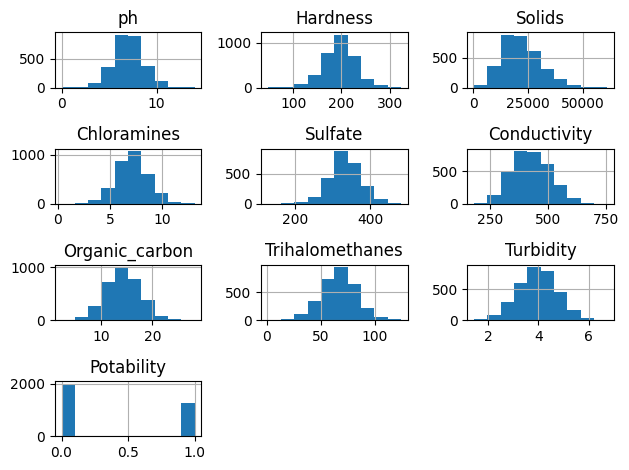

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("변수별 분포 확인\n")
water_df.hist()
plt.tight_layout()
plt.show()


In [ ]:
print("파생 변수 생성(Solids_Cond_Ratio)\n")
water_df['Solids_Cond_Ration'] = water_df['Solids'] / water_df['Conductivity']
display((water_df[['Solids', 'Conductivity', 'Solids_Cond_Ration', 'Potability']]))

파생 변수 생성(Solids_Cond_Ratio)



,Solids,Conductivity,Solids_Cond_Ration,Potability
0,20791.318981,564.308654,36.843878,0
1,18630.057858,592.885359,31.422698,0
2,19909.541732,418.606213,47.561506,0
3,22018.417441,363.266516,60.612296,0
4,17978.986339,398.410813,45.126753,0
...,...,...,...,...
3271,47580.991603,526.424171,90.385271,1
3272,17329.802160,392.449580,44.158035,1
3273,33155.578218,432.044783,76.741068,1
3274,11983.869376,402.883113,29.745276,1


변수 간의 상관계수


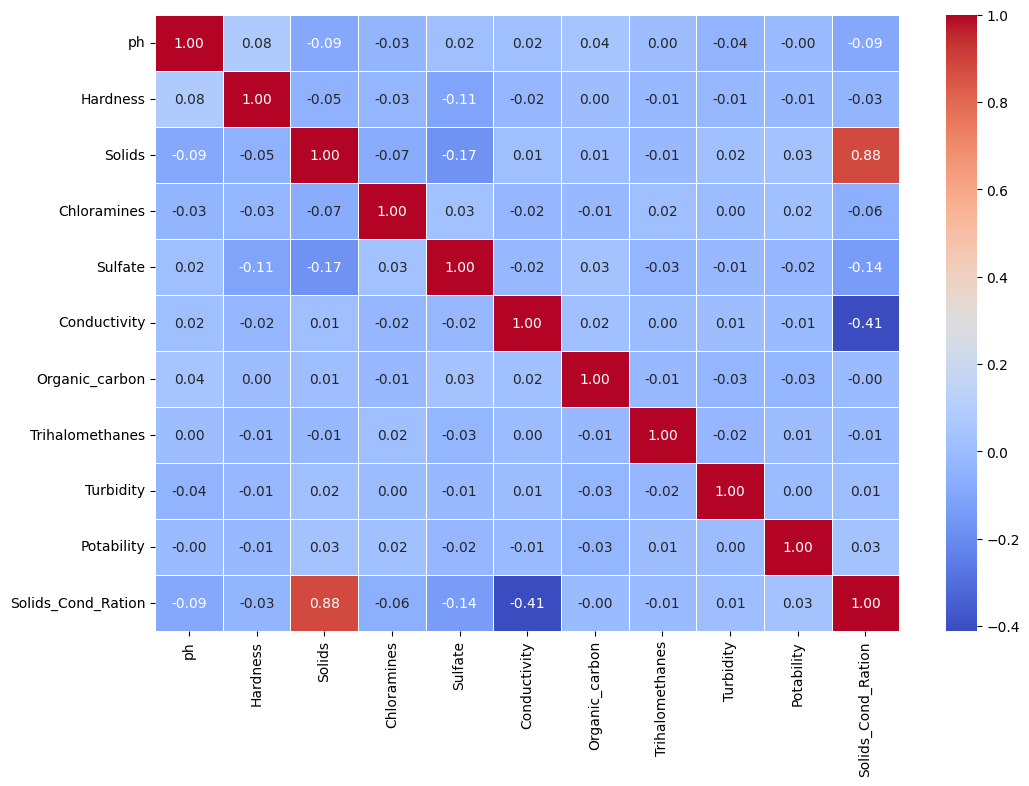

In [ ]:
print("변수 간의 상관계수")
plt.figure(figsize=(12, 8))

sns.heatmap(water_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()

In [ ]:
# 변수 간 상관계수 확인
corr = water_df.corr(numeric_only=True)

# Potability와의 상관계수 확인
target_corr = corr['Potability'].sort_values(ascending=False)
print("[Potability와의 상관계수]")
print(target_corr)

# 낮은 상관계수 변수도 바로 삭제하지 않고 유지
print("\n상관계수는 참고용으로만 사용하고, 변수는 일단 모두 유지합니다.")

[Potability와의 상관계수]
Potability            1.000000
Solids                0.033743
Solids_Cond_Ration    0.031790
Chloramines           0.023779
Trihalomethanes       0.007130
Turbidity             0.001581
ph                   -0.003556
Conductivity         -0.008128
Hardness             -0.013837
Sulfate              -0.023577
Organic_carbon       -0.030001
Name: Potability, dtype: float64

상관계수는 참고용으로만 사용하고, 변수는 일단 모두 유지합니다.


In [ ]:
print("결측치를 중앙값으로 채우기\n")

water_df['ph'] = water_df['ph'].fillna(water_df['ph'].median())
water_df['Sulfate'] = water_df['Sulfate'].fillna(water_df['Sulfate'].median())
water_df['Trihalomethanes'] = water_df['Trihalomethanes'].fillna(water_df['Trihalomethanes'].median())

# 결측치가 잘 채워졌는지 최종 확인
print(water_df.isnull().sum())

결측치를 중앙값으로 채우기

ph                    0
Hardness              0
Solids                0
Chloramines           0
Sulfate               0
Conductivity          0
Organic_carbon        0
Trihalomethanes       0
Turbidity             0
Potability            0
Solids_Cond_Ration    0
dtype: int64


In [ ]:
print("전처리 완료 데이터 저장\n")
water_df.to_csv('new_water_potability.csv', index=False)

전처리 완료 데이터 저장



**3주차**

모든 X,Y 변수를 새로운 데이터프레임으로 추출


In [ ]:
# X (입력 변수들) → 새로운 데이터프레임
X = water_df.drop('Potability', axis=1)

# y (정답 변수) → 새로운 데이터프레임
Y = water_df[['Potability']]

#전체 데이터프레임에서 특정 부분만 '추출'해낸 결과물을 확인
print(X.head())
print(Y.head())
if X.shape[0] == Y.shape[0]:
    print("데이터 개수 일치")

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0  7.036752  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246  333.073546    592.885359   
2  8.099124  224.236259  19909.541732     9.275884  333.073546    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Solids_Cond_Ration  
0       10.379783        86.990970   2.963135           36.843878  
1       15.180013        56.329076   4.500656           31.422698  
2       16.868637        66.420093   3.055934           47.561506  
3       18.436524       100.341674   4.628771           60.612296  
4       11.558279        31.997993   4.075075           45.126753  
   Potability
0           0
1           0
2           0
3           0
4           0
데이터 개수 일치


train test split

In [ ]:
from sklearn.model_selection import train_test_split

# X, y 분리
X = water_df.drop('Potability', axis=1)
y = water_df['Potability']

# train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 클래스 비율 확인
print("전체 데이터 클래스 비율")
print(y.value_counts(normalize=True))

print("\n훈련 데이터 클래스 비율")
print(y_train.value_counts(normalize=True))

print("\n테스트 데이터 클래스 비율")
print(y_test.value_counts(normalize=True))

전체 데이터 클래스 비율
Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64

훈련 데이터 클래스 비율
Potability
0    0.609924
1    0.390076
Name: proportion, dtype: float64

테스트 데이터 클래스 비율
Potability
0    0.609756
1    0.390244
Name: proportion, dtype: float64


모델 학습 및 예측

정확도 (Accuracy): 0.6601
정밀도 (Precision): 0.5954
재현율 (Recall): 0.4023
F1-score: 0.4802

상세 보고서:
              precision    recall  f1-score   support

           0       0.68      0.82      0.75       400
           1       0.60      0.40      0.48       256

    accuracy                           0.66       656
   macro avg       0.64      0.61      0.61       656
weighted avg       0.65      0.66      0.64       656



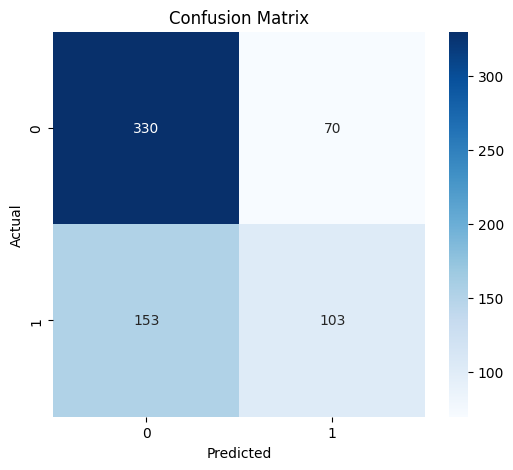

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 모델 생성
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

# 2. 모델 학습
rf_model.fit(X_train, y_train)

# 3. 예측
y_pred = rf_model.predict(X_test)

# 4. 평가
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"정확도 (Accuracy): {acc:.4f}")
print(f"정밀도 (Precision): {prec:.4f}")
print(f"재현율 (Recall): {rec:.4f}")
print(f"F1-score: {f1:.4f}")

print("\n상세 보고서:")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# -------------------------
# 1. Baseline 모델
# -------------------------
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

print("=== Baseline RF ===")
print("Accuracy :", round(accuracy_score(y_test, baseline_pred), 4))
print("Precision:", round(precision_score(y_test, baseline_pred), 4))
print("Recall   :", round(recall_score(y_test, baseline_pred), 4))
print("F1-score :", round(f1_score(y_test, baseline_pred), 4))

# -------------------------
# 2. Modified 모델
# -------------------------
modified_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
modified_model.fit(X_train, y_train)
modified_pred = modified_model.predict(X_test)

print("\n=== Modified RF ===")
print("Accuracy :", round(accuracy_score(y_test, modified_pred), 4))
print("Precision:", round(precision_score(y_test, modified_pred), 4))
print("Recall   :", round(recall_score(y_test, modified_pred), 4))
print("F1-score :", round(f1_score(y_test, modified_pred), 4))

=== Baseline RF ===
Accuracy : 0.6479
Precision: 0.5969
Recall   : 0.3008
F1-score : 0.4

=== Modified RF ===
Accuracy : 0.6601
Precision: 0.5954
Recall   : 0.4023
F1-score : 0.4802


교차 검증 후 성능 비교

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 비교할 모델 2개
model_default = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

# StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 평가 지표
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 교차검증
cv_default = cross_validate(model_default, X_train, y_train, cv=skf, scoring=scoring)
cv_balanced = cross_validate(model_balanced, X_train, y_train, cv=skf, scoring=scoring)

# 평균 성능 정리
cv_result = pd.DataFrame({
    'Model': ['Default RF', 'Balanced RF'],
    'Accuracy': [cv_default['test_accuracy'].mean(), cv_balanced['test_accuracy'].mean()],
    'Precision': [cv_default['test_precision'].mean(), cv_balanced['test_precision'].mean()],
    'Recall': [cv_default['test_recall'].mean(), cv_balanced['test_recall'].mean()],
    'F1-score': [cv_default['test_f1'].mean(), cv_balanced['test_f1'].mean()]
})

print(cv_result)

         Model  Accuracy  Precision    Recall  F1-score
0   Default RF  0.670992   0.654890  0.330708  0.438660
1  Balanced RF  0.665649   0.611774  0.390387  0.475398


GridSearch CV

=== RandomForest 고정 파라미터 모델 결과 ===
정확도 (Accuracy): 0.6601
정밀도 (Precision): 0.5954
재현율 (Recall): 0.4023
F1-score: 0.4802

상세 보고서:
              precision    recall  f1-score   support

           0       0.68      0.82      0.75       400
           1       0.60      0.40      0.48       256

    accuracy                           0.66       656
   macro avg       0.64      0.61      0.61       656
weighted avg       0.65      0.66      0.64       656



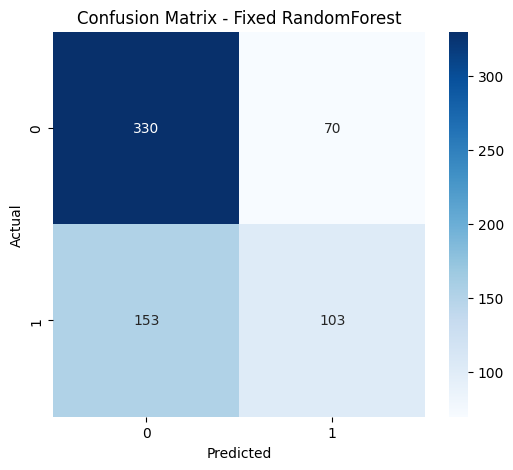

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# GridSearch 대신 고정 파라미터 RandomForest 사용
# ============================================================

best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 학습
best_model.fit(X_train, y_train)

# 예측
y_pred_best = best_model.predict(X_test)

# 평가
acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best)
rec = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print("=== RandomForest 고정 파라미터 모델 결과 ===")
print(f"정확도 (Accuracy): {acc:.4f}")
print(f"정밀도 (Precision): {prec:.4f}")
print(f"재현율 (Recall): {rec:.4f}")
print(f"F1-score: {f1:.4f}")

print("\n상세 보고서:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Fixed RandomForest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

임계값 조정

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# 1. 확률 예측
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 2. 여러 threshold 비교
thresholds = np.arange(0.30, 0.71, 0.05)

results = []

for th in thresholds:
    y_pred_th = (y_pred_proba >= th).astype(int)

    acc = accuracy_score(y_test, y_pred_th)
    prec = precision_score(y_test, y_pred_th)
    rec = recall_score(y_test, y_pred_th)
    f1 = f1_score(y_test, y_pred_th)

    results.append([th, acc, prec, rec, f1])

threshold_df = pd.DataFrame(
    results,
    columns=['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

print(threshold_df)

# 3. F1-score가 가장 높은 threshold 선택
best_row = threshold_df.loc[threshold_df['F1-score'].idxmax()]
best_threshold = best_row['Threshold']

print(f"\n최적 Threshold: {best_threshold:.2f}")
print(best_row)

   Threshold  Accuracy  Precision    Recall  F1-score
0       0.30  0.429878   0.405145  0.984375  0.574032
1       0.35  0.466463   0.418403  0.941406  0.579327
2       0.40  0.536585   0.451220  0.867188  0.593583
3       0.45  0.614329   0.504505  0.656250  0.570458
4       0.50  0.660061   0.595376  0.402344  0.480186
5       0.55  0.669207   0.746835  0.230469  0.352239
6       0.60  0.661585   0.826923  0.167969  0.279221
7       0.65  0.641768   0.888889  0.093750  0.169611
8       0.70  0.629573   1.000000  0.050781  0.096654

최적 Threshold: 0.40
Threshold    0.400000
Accuracy     0.536585
Precision    0.451220
Recall       0.867188
F1-score     0.593583
Name: 2, dtype: float64


정밀도와 재현율이 100% 되는 경우

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

# 1. 모델이 클래스 1(음용 가능)로 분류할 확률을 가져옵니다.
# rf_model 대신 학습이 완료된 best_model을 사용합니다.
y_scores = best_model.predict_proba(X_test)[:, 1]

# --- 케이스 A: 재현율(Recall)을 100%로 만들기 ---
# 임계값을 0으로 설정하면 모델이 모든 데이터를 '1'이라고 예측합니다.
threshold_low = 0.0
y_pred_recall_100 = (y_scores >= threshold_low).astype(int)

# --- 케이스 B: 정밀도(Precision)를 100%로 만들기 ---
# 임계값을 1에 가깝게 설정하여 모델이 '확실한 것'만 1이라고 예측하게 합니다.
# (예측 확률 중 최대값보다 높게 설정하면 아무것도 선택 안 하므로 최대값으로 설정)
threshold_high = np.max(y_scores)
y_pred_precision_100 = (y_scores >= threshold_high).astype(int)

print(f"[임계값 {threshold_low} (매우 낮음)]")
print(f"재현율: {recall_score(y_test, y_pred_recall_100):.2f} (실제 양성을 하나도 놓치지 않음)")
print(f"정밀도: {precision_score(y_test, y_pred_recall_100):.2f}")

print(f"\n[임계값 {threshold_high:.2f} (매우 높음)]")
print(f"정밀도: {precision_score(y_test, y_pred_precision_100):.2f} (예측한 양성은 모두 정답임)")
print(f"재현율: {recall_score(y_test, y_pred_precision_100):.2f}")

[임계값 0.0 (매우 낮음)]
재현율: 1.00 (실제 양성을 하나도 놓치지 않음)
정밀도: 0.39

[임계값 0.88 (매우 높음)]
정밀도: 1.00 (예측한 양성은 모두 정답임)
재현율: 0.00


오차 행렬(Confusion matrix) 만들어서 예측 오류값이 얼마인지 어떠한 유형의 예측 오류가 일어나고 있는지 확인해보기

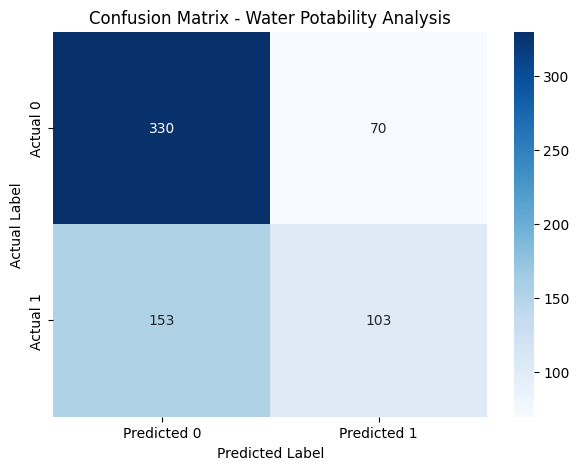

--- [예측 오류 분석 결과] ---
전체 테스트 데이터 수: 656건
전체 예측 오류 발생: 223건
------------------------------
유형 1: 가양성 (False Positive) -> 70건
  - 실제는 마실 수 없으나(0), 마실 수 있다(1)고 오판
  - 위험성: 건강 및 생명에 직접적인 위협을 주는 치명적 오류
------------------------------
유형 2: 가음성 (False Negative) -> 153건
  - 실제는 마실 수 있으나(1), 마실 수 없다(0)고 오판
  - 위험성: 가용한 수자원을 낭비하게 되는 경제적 손실
------------------------------
오류 비율 분석: 가음성(FN)이 가양성(FP)보다 약 2.2배 더 많이 발생 중


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 오차 행렬 계산
# TN: 마실 수 없는 물을 정확히 예측
# FP: 마실 수 없는 물을 마실 수 있다고 오판 (치명적 오류)
# FN: 마실 수 있는 물을 마실 수 없다고 오판 (자원 낭비)
# TP: 마실 수 있는 물을 정확히 예측
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# 2. 오차 행렬 시각화
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Water Potability Analysis')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# 3. 예측 오류 수치 및 유형 분석 결과 출력
print("--- [예측 오류 분석 결과] ---")
print(f"전체 테스트 데이터 수: {len(y_test)}건")
print(f"전체 예측 오류 발생: {fp + fn}건")
print("-" * 30)
print(f"유형 1: 가양성 (False Positive) -> {fp}건")
print("  - 실제는 마실 수 없으나(0), 마실 수 있다(1)고 오판")
print("  - 위험성: 건강 및 생명에 직접적인 위협을 주는 치명적 오류")
print("-" * 30)
print(f"유형 2: 가음성 (False Negative) -> {fn}건")
print("  - 실제는 마실 수 있으나(1), 마실 수 없다(0)고 오판")
print("  - 위험성: 가용한 수자원을 낭비하게 되는 경제적 손실")
print("-" * 30)
print(f"오류 비율 분석: 가음성(FN)이 가양성(FP)보다 약 {fn/fp:.1f}배 더 많이 발생 중")

임계값 조정을 통해 다양한 평가 지표의 변화를 확인해보기

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. 모델이 클래스 1(음용 가능)로 분류할 확률을 계산합니다.
# rf_model은 이미 학습(fit)된 상태여야 합니다.
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 2. 여러 임계값을 적용하여 지표를 계산하는 함수 정의
def get_evaluation_by_thresholds(y_test, y_pred_proba, thresholds):
    evaluation_results = []

    for threshold in thresholds:
        # 설정한 임계값보다 확률이 크면 1, 작으면 0으로 예측값 생성
        custom_predict = (y_pred_proba >= threshold).astype(int)

        # 각 지표 계산
        acc = accuracy_score(y_test, custom_predict)
        prec = precision_score(y_test, custom_predict)
        rec = recall_score(y_test, custom_predict)
        f1 = f1_score(y_test, custom_predict)

        evaluation_results.append([threshold, acc, prec, rec, f1])

    # 결과를 데이터프레임으로 변환하여 출력
    result_df = pd.DataFrame(evaluation_results,
                             columns=['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-score'])
    return result_df

# 3. 테스트할 임계값 리스트 설정 (0.5를 기준으로 하향 조정)
threshold_list = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25]

# 4. 결과 출력
evaluation_df = get_evaluation_by_thresholds(y_test, y_pred_proba, threshold_list)
print("--- 임계값 변화에 따른 성능 지표 변화 ---")
print(evaluation_df)

--- 임계값 변화에 따른 성능 지표 변화 ---
   Threshold  Accuracy  Precision    Recall  F1-score
0       0.50  0.660061   0.595376  0.402344  0.480186
1       0.45  0.614329   0.504505  0.656250  0.570458
2       0.40  0.536585   0.451220  0.867188  0.593583
3       0.35  0.466463   0.418403  0.941406  0.579327
4       0.30  0.429878   0.405145  0.984375  0.574032
5       0.25  0.403963   0.395672  1.000000  0.566999


ROC곡선 그려보고 AUC스코어 확인해보기

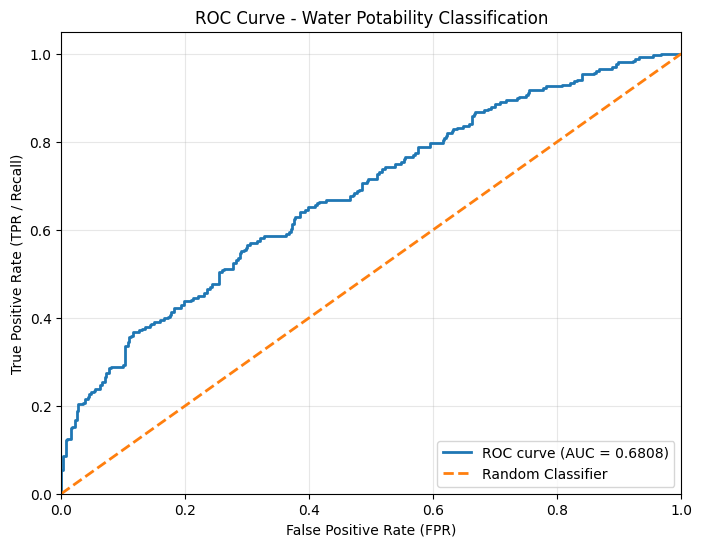

ROC-AUC 점수: 0.6808


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. 양성 클래스(1: 음용 가능) 확률 예측
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 2. ROC Curve 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. AUC 계산
auc_score = roc_auc_score(y_test, y_pred_proba)

# 4. ROC Curve 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('ROC Curve - Water Potability Classification')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC 점수: {auc_score:.4f}")

예측 결과 파일 생성 및 제출

In [ ]:
import pandas as pd
import numpy as np

# =========================================
# 1. 최종 사용할 모델 선택
# =========================================
final_model = best_model if 'best_model' in globals() else rf_model

# =========================================
# 2. 예측값 및 예측확률 생성
# =========================================
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

custom_threshold = 0.30
y_pred = (y_pred_proba >= custom_threshold).astype(int)

# =========================================
# 3. 결과 저장용 데이터프레임 생성
# =========================================
result_df = X_test.copy()
result_df = result_df.reset_index(drop=True)

result_df['Actual'] = y_test.reset_index(drop=True)
result_df['Predicted'] = y_pred
result_df['Predicted_Prob_Class1'] = y_pred_proba
result_df['Correct'] = (result_df['Actual'] == result_df['Predicted']).astype(int)

# =========================================
# 4. CSV 저장
# =========================================
result_df.to_csv("test_prediction_result.csv", index=False, encoding="utf-8-sig")

# =========================================
# 5. 확인 출력
# =========================================
print("예측 결과 파일 생성 완료!")
print("파일명: test_prediction_result.csv")
print(result_df.head())

예측 결과 파일 생성 완료!
파일명: test_prediction_result.csv
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0  7.036752  188.743562  19037.462638     6.034236  333.073546    388.065857   
1  6.172517  187.787017  10498.635154     7.722561  322.521035    467.090425   
2  7.036752  176.386651  26003.163265     7.809251  358.429774    336.142005   
3  6.369112  235.340943  34456.801132     9.170940  295.350524    357.417285   
4  6.140878  197.876090  26687.874483     7.587196  329.231853    548.072761   

   Organic_carbon  Trihalomethanes  Turbidity  Solids_Cond_Ration  Actual  \
0       15.149068        78.499418   2.723651           49.057299       1   
1       21.233978        68.163642   4.129985           22.476665       0   
2       14.447961        90.224844   4.410674           77.357673       0   
3        9.213268        59.280269   2.275903           96.404966       0   
4       15.836330        41.263648   5.359460           48.694035       0   

   Predi

K-Means 클러스터링 연계코드

In [ ]:
# ============================================================
# train/test 데이터 다시 정의
# ============================================================

from sklearn.model_selection import train_test_split

# water_df가 기존 전처리 완료된 데이터프레임이라고 가정
X = water_df.drop('Potability', axis=1)
y = water_df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (2620, 10)
X_test shape : (656, 10)
y_train shape: (2620,)
y_test shape : (656,)


K-Means 군집 feature 생성 + RandomForest 재학습

기존 feature 수: 10
K-Means 군집 feature 추가 후 feature 수: 13

[훈련 데이터 군집 분포]
0    965
1    926
2    729
Name: count, dtype: int64

[테스트 데이터 군집 분포]
0    230
1    213
2    213
Name: count, dtype: int64

=== [K-Means 군집 feature 추가 후] RandomForest 분류 결과 ===
Accuracy : 0.6524
Precision: 0.5824
Recall   : 0.3867
F1-score : 0.4648

상세 보고서:
              precision    recall  f1-score   support

           0       0.68      0.82      0.74       400
           1       0.58      0.39      0.46       256

    accuracy                           0.65       656
   macro avg       0.63      0.60      0.60       656
weighted avg       0.64      0.65      0.63       656



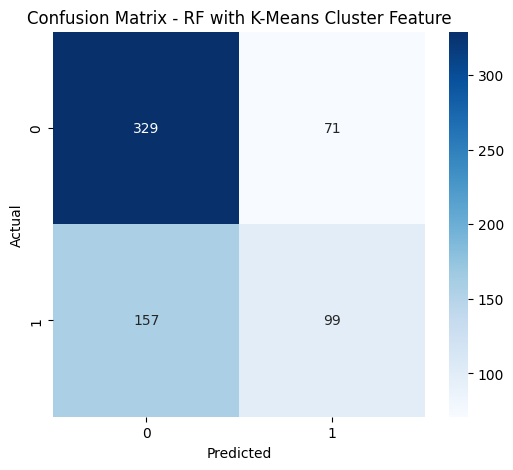

In [ ]:
# ============================================================
#  K-Means 군집 feature 추가 후 RandomForest 재학습
# ============================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. K-Means는 거리 기반 알고리즘이므로 독립변수 스케일링
# ------------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 2. K-Means 군집화
#    Potability는 사용하지 않고 X 변수만 사용
# ------------------------------------------------------------
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train_scaled).reshape(-1, 1)
test_clusters = kmeans.predict(X_test_scaled).reshape(-1, 1)

# ------------------------------------------------------------
# 3. 군집 번호를 One-Hot Encoding
# ------------------------------------------------------------
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

train_cluster_encoded = encoder.fit_transform(train_clusters)
test_cluster_encoded = encoder.transform(test_clusters)

# ------------------------------------------------------------
# 4. 기존 독립변수에 K-Means 군집 feature 추가
# ------------------------------------------------------------
X_train_cluster_added = np.hstack([X_train_scaled, train_cluster_encoded])
X_test_cluster_added = np.hstack([X_test_scaled, test_cluster_encoded])

print("기존 feature 수:", X_train.shape[1])
print("K-Means 군집 feature 추가 후 feature 수:", X_train_cluster_added.shape[1])

print("\n[훈련 데이터 군집 분포]")
print(pd.Series(train_clusters.flatten()).value_counts().sort_index())

print("\n[테스트 데이터 군집 분포]")
print(pd.Series(test_clusters.flatten()).value_counts().sort_index())

# ------------------------------------------------------------
# 5. RandomForest 모델 학습
# ------------------------------------------------------------
rf_cluster = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_cluster.fit(X_train_cluster_added, y_train)

# ------------------------------------------------------------
# 6. 예측 및 성능 평가
# ------------------------------------------------------------
y_pred_cluster = rf_cluster.predict(X_test_cluster_added)

acc_cluster = accuracy_score(y_test, y_pred_cluster)
prec_cluster = precision_score(y_test, y_pred_cluster)
rec_cluster = recall_score(y_test, y_pred_cluster)
f1_cluster = f1_score(y_test, y_pred_cluster)

print("\n=== [K-Means 군집 feature 추가 후] RandomForest 분류 결과 ===")
print(f"Accuracy : {acc_cluster:.4f}")
print(f"Precision: {prec_cluster:.4f}")
print(f"Recall   : {rec_cluster:.4f}")
print(f"F1-score : {f1_cluster:.4f}")

print("\n상세 보고서:")
print(classification_report(y_test, y_pred_cluster))

# ------------------------------------------------------------
# 7. Confusion Matrix 시각화
# ------------------------------------------------------------
cm_cluster = confusion_matrix(y_test, y_pred_cluster)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_cluster, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RF with K-Means Cluster Feature")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

기존 모델과 K-Means 추가 모델 비교

=== 모델 성능 비교 ===
                            Model  Accuracy  Precision    Recall  F1-score
0                 기존 RandomForest  0.660061   0.595376  0.402344  0.480186
1  RandomForest + K-Means Cluster  0.652439   0.582353  0.386719  0.464789


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


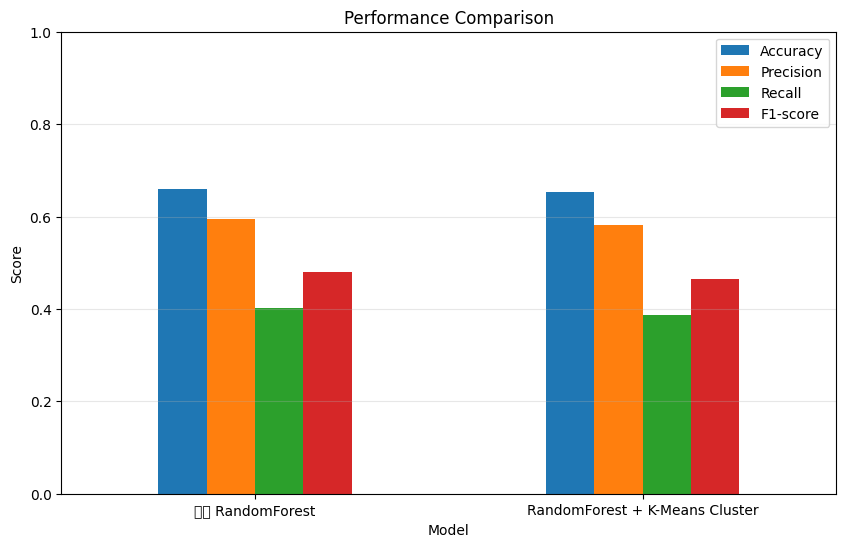

In [ ]:
# ============================================================
# 3. 기존 RandomForest vs K-Means feature 추가 모델 성능 비교
# ============================================================

comparison_df = pd.DataFrame({
    'Model': [
        '기존 RandomForest',
        'RandomForest + K-Means Cluster'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_cluster)
    ],
    'Precision': [
        precision_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_cluster)
    ],
    'Recall': [
        recall_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_cluster)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_cluster)
    ]
})

print("=== 모델 성능 비교 ===")
print(comparison_df)

# 그래프
comparison_df.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title("Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()